In [15]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import os

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv(override=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in your .env file")


In [16]:
pdf_files = [
    "./Docs/Company_Policies.pdf",
    "./Docs/Company_Profile.pdf",
    "./Docs/Product_and_Pricing.pdf",
]

docs = []
for file_path in pdf_files:
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")
    docs.extend(PyPDFLoader(file_path).load())

print(f"Loaded {len(docs)} pages")


Loaded 8 pages


In [17]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [18]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6939.64it/s]


In [19]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=GROQ_API_KEY
)


In [20]:
# --------------------------------------------------
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]

    answer: str

In [21]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [22]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [23]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer the question using ONLY the provided context.\n"
            "If the answer is not in the context, say 'I don't know based on the provided documents.'\n\n"
            "Context:\n{context}"
        ),
        ("human", "{question}"),
    ]
)

def generate_rag(state: State):
    context = "\n\n".join([d.page_content for d in state["docs"]])
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            context=context,
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [24]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

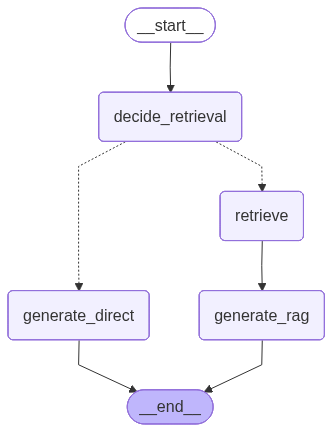

In [25]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("generate_rag", generate_rag)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("retrieve", "generate_rag")
g.add_edge("generate_rag", END)
g.add_edge("generate_direct", END)

app = g.compile()
app

In [26]:
result = app.invoke(
    {
        "question": "What is Machine Learning?",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])
print("Retrieval used:", result["need_retrieval"])


Machine Learning (ML) is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to learn from data, make decisions, and improve their performance on a task without being explicitly programmed.

In traditional programming, a computer is given a set of rules and instructions to follow. However, with machine learning, the computer is given a set of data and learns to make predictions, classify objects, or make decisions based on that data.

The process of machine learning typically involves the following steps:

1. Data collection: Gathering data relevant to the task at hand.
2. Data preprocessing: Cleaning, transforming, and preparing the data for use.
3. Model selection: Choosing a suitable machine learning algorithm and configuring it.
4. Training: Feeding the data to the algorithm, which learns to make predictions or take actions.
5. Testing: Evaluating the performance of the trained model on new, unseen data.
6. Deployme

In [27]:
result['need_retrieval']

False

In [28]:
result['docs']

[]